# The Bias-Variance Tradeoff


## Why Models Fail

Every machine learning model can fail in two fundamentally different ways:

1. **Too rigid:** the model can't capture the true patterns in data
2. **Too flexible:** the model memorizes noise instead of learning signal

Understanding this tension is essential for building models that generalize well. The **bias-variance tradeoff** formalizes this intuition and explains why there's no free lunch: reducing one type of error typically increases the other.

In this notebook, we'll:
- Visualize underfitting and overfitting with polynomial regression
- Define bias and variance mathematically
- Explore how model complexity affects generalization
- Learn practical strategies for finding the right balance

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## A Concrete Example: Polynomial Fitting

Suppose the true relationship between $x$ and $y$ is quadratic, but we only observe noisy samples. What happens when we fit models of different complexity?

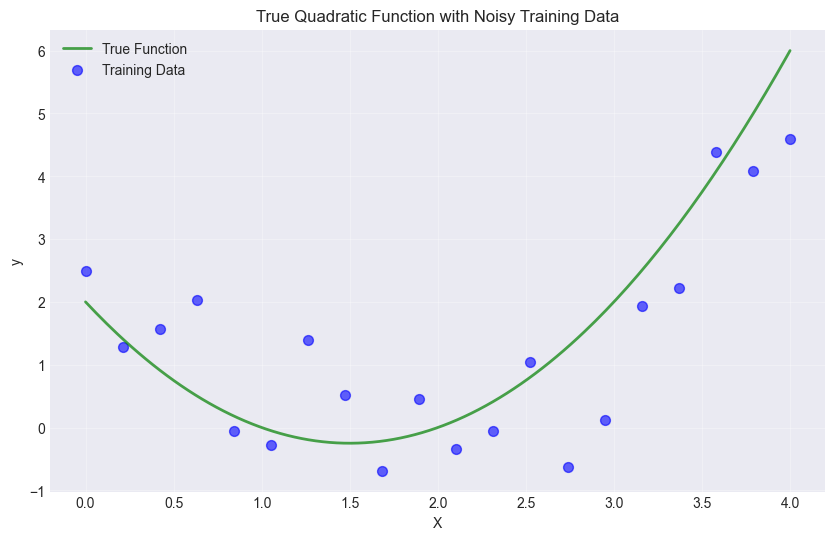

In [2]:
# Generate true quadratic data with noise
def true_function(x):
    return x**2 - 3*x + 2

# Training data
X_train = np.linspace(0, 4, 20)
y_train = true_function(X_train) + np.random.normal(0, 1, 20)

# Test data (for evaluation)
X_test = np.linspace(0, 4, 50)
y_test = true_function(X_test) + np.random.normal(0, 0.5, 50)

# Reshape for sklearn
X_train_r = X_train.reshape(-1, 1)
X_test_r = X_test.reshape(-1, 1)

# Plot the true function and training data
plt.figure(figsize=(10, 6))
x_smooth = np.linspace(0, 4, 200)
plt.plot(x_smooth, true_function(x_smooth), 'g-', label='True Function', linewidth=2, alpha=0.7)
plt.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('True Quadratic Function with Noisy Training Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model Complexity Spectrum

Let's fit three models representing different points on the complexity spectrum:

| Model | Complexity | Expected Behavior |
|-------|------------|-------------------|
| Linear (degree 1) | Low | May miss curvature |
| Quadratic (degree 2) | Medium | Should match true function |
| Degree 15 polynomial | High | Risk of fitting noise |

### 1. Linear Model - Too Simple

Linear Model:
  Training MSE: 2.127
  Test MSE: 2.252


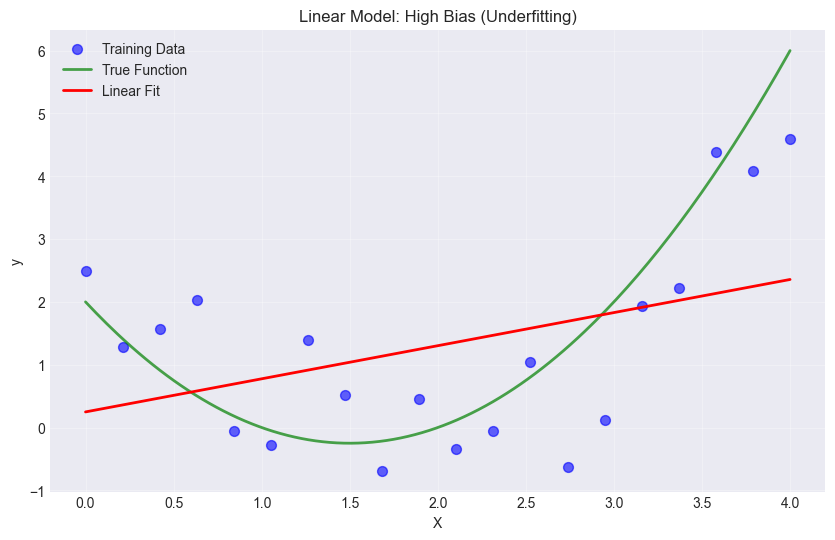

In [4]:
# Fit a linear model
linear_model = LinearRegression()
linear_model.fit(X_train_r, y_train)

# Make predictions
y_train_pred_linear = linear_model.predict(X_train_r)
y_test_pred_linear = linear_model.predict(X_test_r)

# Calculate errors
train_mse_linear = mean_squared_error(y_train, y_train_pred_linear)
test_mse_linear = mean_squared_error(y_test, y_test_pred_linear)

print(f"Linear Model:")
print(f"  Training MSE: {train_mse_linear:.3f}")
print(f"  Test MSE: {test_mse_linear:.3f}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training Data')
plt.plot(x_smooth, true_function(x_smooth), 'g-', label='True Function', linewidth=2, alpha=0.7)
x_smooth_r = x_smooth.reshape(-1, 1)
plt.plot(x_smooth, linear_model.predict(x_smooth_r), 'r-', label='Linear Fit', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Model: High Bias (Underfitting)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The linear model systematically misses the curvature. No matter how much data we show it, a line cannot represent a parabola. This systematic error is the **bias**. Bias means that the model's assumptions prevent it from capturing the true relationship.

### 2. Quadratic Model - Just Right

Quadratic Model:
  Training MSE: 0.543
  Test MSE: 0.583


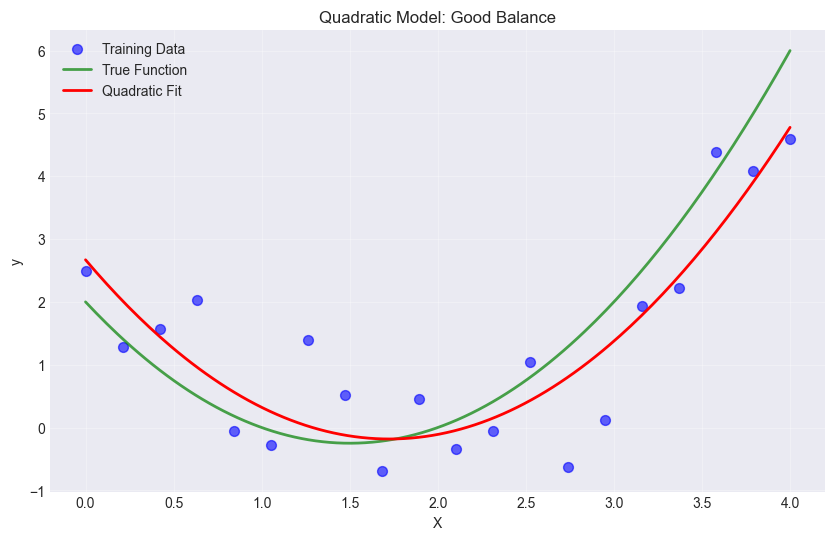

In [5]:
# Fit a quadratic model
quadratic_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])
quadratic_model.fit(X_train_r, y_train)

# Make predictions
y_train_pred_quad = quadratic_model.predict(X_train_r)
y_test_pred_quad = quadratic_model.predict(X_test_r)

# Calculate errors
train_mse_quad = mean_squared_error(y_train, y_train_pred_quad)
test_mse_quad = mean_squared_error(y_test, y_test_pred_quad)

print(f"Quadratic Model:")
print(f"  Training MSE: {train_mse_quad:.3f}")
print(f"  Test MSE: {test_mse_quad:.3f}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training Data')
plt.plot(x_smooth, true_function(x_smooth), 'g-', label='True Function', linewidth=2, alpha=0.7)
plt.plot(x_smooth, quadratic_model.predict(x_smooth_r), 'r-', label='Quadratic Fit', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Quadratic Model: Good Balance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The quadratic model matches the true function's form. It has enough flexibility to capture the pattern but not so much that it chases noise. This is the sweet spot.

### 3. High-Degree Polynomial - Too Flexible

High-Degree Polynomial Model:
  Training MSE: 0.183
  Test MSE: 1.579


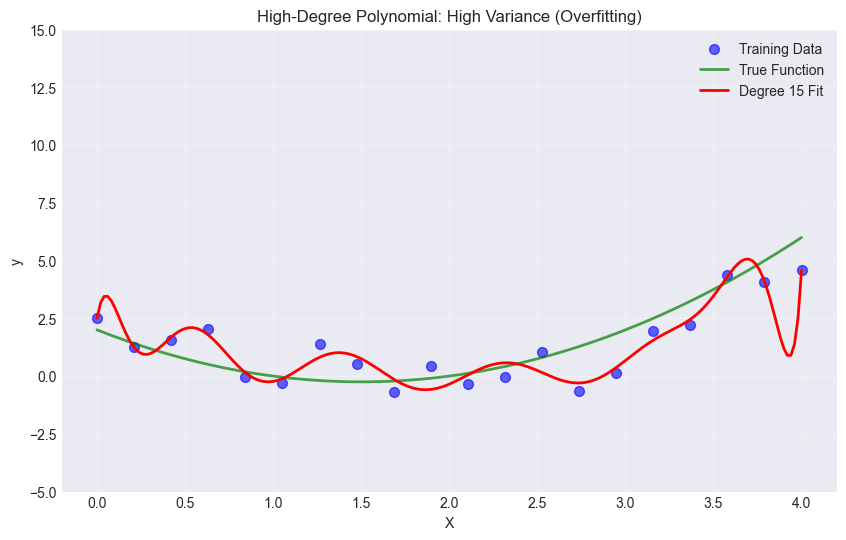

In [8]:
# Fit a high-degree polynomial
high_poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('linear', LinearRegression())
])
high_poly_model.fit(X_train_r, y_train)

# Make predictions
y_train_pred_poly = high_poly_model.predict(X_train_r)
y_test_pred_poly = high_poly_model.predict(X_test_r)

# Calculate errors
train_mse_poly = mean_squared_error(y_train, y_train_pred_poly)
test_mse_poly = mean_squared_error(y_test, y_test_pred_poly)

print(f"High-Degree Polynomial Model:")
print(f"  Training MSE: {train_mse_poly:.3f}")
print(f"  Test MSE: {test_mse_poly:.3f}")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training Data')
plt.plot(x_smooth, true_function(x_smooth), 'g-', label='True Function', linewidth=2, alpha=0.7)
plt.plot(x_smooth, high_poly_model.predict(x_smooth_r), 'r-', label='Degree 15 Fit', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('High-Degree Polynomial: High Variance (Overfitting)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-5, 15)
plt.show()

The degree-15 polynomial passes near every training point but oscillates wildly between them. It has learned the noise as if it were signal. This sensitivity to the specific training sample is **variance**, a different training set would produce a very different fit. It seems like the model is almost memorizing every point, one by one.

## Side-by-Side Comparison


Model Comparison:
               Model  Training MSE  Test MSE              Characteristic
              Linear      2.127227  2.252083    High Bias (Underfitting)
           Quadratic      0.542992  0.582594                Good Balance
Degree 15 Polynomial      0.183194  1.578515 High Variance (Overfitting)


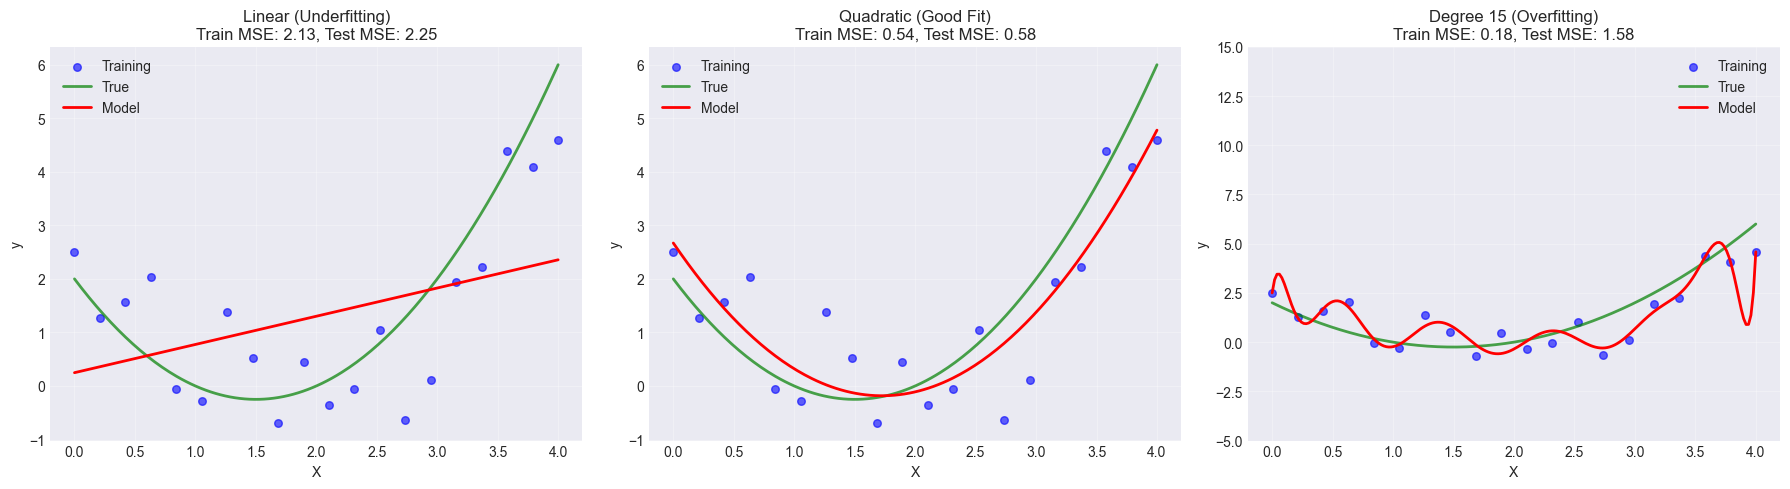

In [9]:
# Create comparison table
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear', 'Quadratic', 'Degree 15 Polynomial'],
    'Training MSE': [train_mse_linear, train_mse_quad, train_mse_poly],
    'Test MSE': [test_mse_linear, test_mse_quad, test_mse_poly],
    'Characteristic': ['High Bias (Underfitting)', 'Good Balance', 'High Variance (Overfitting)']
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))

# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [linear_model, quadratic_model, high_poly_model]
titles = ['Linear (Underfitting)', 'Quadratic (Good Fit)', 'Degree 15 (Overfitting)']
train_errors = [train_mse_linear, train_mse_quad, train_mse_poly]
test_errors = [test_mse_linear, test_mse_quad, test_mse_poly]

for ax, model, title, train_err, test_err in zip(axes, models, titles, train_errors, test_errors):
    ax.scatter(X_train, y_train, color='blue', s=30, alpha=0.6, label='Training')
    ax.plot(x_smooth, true_function(x_smooth), 'g-', linewidth=2, alpha=0.7, label='True')
    ax.plot(x_smooth, model.predict(x_smooth_r), 'r-', linewidth=2, label='Model')
    ax.set_title(f'{title}\nTrain MSE: {train_err:.2f}, Test MSE: {test_err:.2f}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if title.startswith('Degree'):
        ax.set_ylim(-5, 15)

plt.tight_layout()
plt.show()

## Defining Bias and Variance

### Bias: Systematic Error from Model Assumptions

**Bias** measures how far off the model's average prediction is from the true value, across all possible training sets. Bias is the persistent offset between the expected learned predictor and the true mapping. So it captures what remains wrong even after averaging out sampling noise (variance).

- High-bias models make strong simplifying assumptions
- They consistently miss the target in the same direction
- More data doesn't help, the model structure is wrong
- *Symptom*: Both training and test errors are high

### Variance: Sensitivity to Training Data

**Variance** measures how much predictions fluctuate when trained on different samples from the same distribution.

- High-variance models are very flexible
- They fit training data tightly but differently each time
- The model "remembers" noise rather than learning patterns
- *Symptom*: Low training error, high test error (gap between them)

### The Fundamental Tension

These errors work against each other:

- **Increase complexity:** bias ↓, variance ↑
- **Decrease complexity:** bias ↑, variance ↓

You cannot minimize both simultaneously. The goal is to find the complexity level where their *sum* is smallest.

## The Mathematical Decomposition

For a given input $x$, the expected prediction error decomposes as:

$$\mathbb{E}[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}[\hat{f}(x)]^2}_{\text{systematic error}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{estimation error}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

Where:
- **Bias²**: $(\mathbb{E}[\hat{f}(x)] - f(x))^2$, how wrong the model is on average
- **Variance**: $\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]$, how much $\hat{f}$ varies across training sets
- **Irreducible error** ($\sigma^2$): noise in the data itself, no model can reduce this

Since we can't control $\sigma^2$, our job is to balance bias² and variance to minimize total error.

## Visualizing the Tradeoff

Let's see how training and test error evolve as we increase polynomial degree:

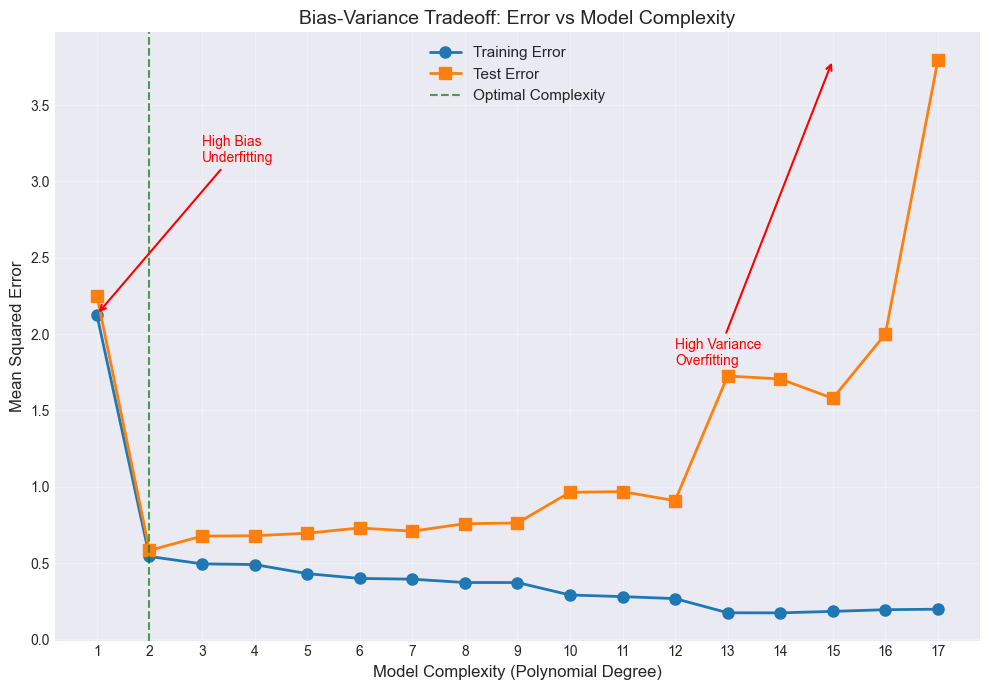


Key Observations:
- As complexity increases, training error decreases monotonically
- Test error first decreases, then increases (U-shaped curve)
- Optimal complexity is around degree 2
- Minimum test error: 0.583


In [10]:
# Test different polynomial degrees
degrees = range(1, 18)
train_errors = []
test_errors = []

for degree in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    model.fit(X_train_r, y_train)
    
    train_pred = model.predict(X_train_r)
    test_pred = model.predict(X_test_r)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

# Plot
plt.figure(figsize=(10, 7))
plt.plot(degrees, train_errors, 'o-', label='Training Error', linewidth=2, markersize=8)
plt.plot(degrees, test_errors, 's-', label='Test Error', linewidth=2, markersize=8)
plt.axvline(x=2, color='green', linestyle='--', alpha=0.7, label='Optimal Complexity')
plt.xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Bias-Variance Tradeoff: Error vs Model Complexity', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(degrees)

# Add annotations
plt.annotate('High Bias\nUnderfitting', xy=(1, train_errors[0]), xytext=(3, train_errors[0]+1),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, color='red')
plt.annotate('High Variance\nOverfitting', xy=(15, test_errors[-1]), xytext=(12, test_errors[-1]-2),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, color='red')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- As complexity increases, training error decreases monotonically")
print("- Test error first decreases, then increases (U-shaped curve)")
print(f"- Optimal complexity is around degree {degrees[np.argmin(test_errors)]}")
print(f"- Minimum test error: {min(test_errors):.3f}")

## Diagnosing Your Model

### Signs of Underfitting (High Bias)

| Indicator | What You See |
|-----------|-------------|
| Training error | High |
| Test error | High |
| Gap (test - train) | Small |
| Learning curve | Both errors plateau high |

**Remedies:**
- Increase model capacity (more layers, higher degree, more trees)
- Add informative features
- Reduce regularization strength
- Train longer (for iterative methods)

### Signs of Overfitting (High Variance)

| Indicator | What You See |
|-----------|-------------|
| Training error | Low |
| Test error | High |
| Gap (test - train) | Large |
| Learning curve | Training error much lower than validation |

**Remedies:**
- Get more training data
- Reduce model capacity
- Add regularization (L1, L2, dropout)
- Use cross-validation to tune hyperparameters
- Apply early stopping
- Feature selection / dimensionality reduction

### Signs of Good Fit

| Indicator | What You See |
|-----------|-------------|
| Training error | Low |
| Test error | Low |
| Gap (test - train) | Small |
| Performance | Acceptable for your use case |

## The Effect of Training Set Size

More data is one of the most effective ways to combat overfitting. Let's see how a complex model behaves with increasing amounts of training data:

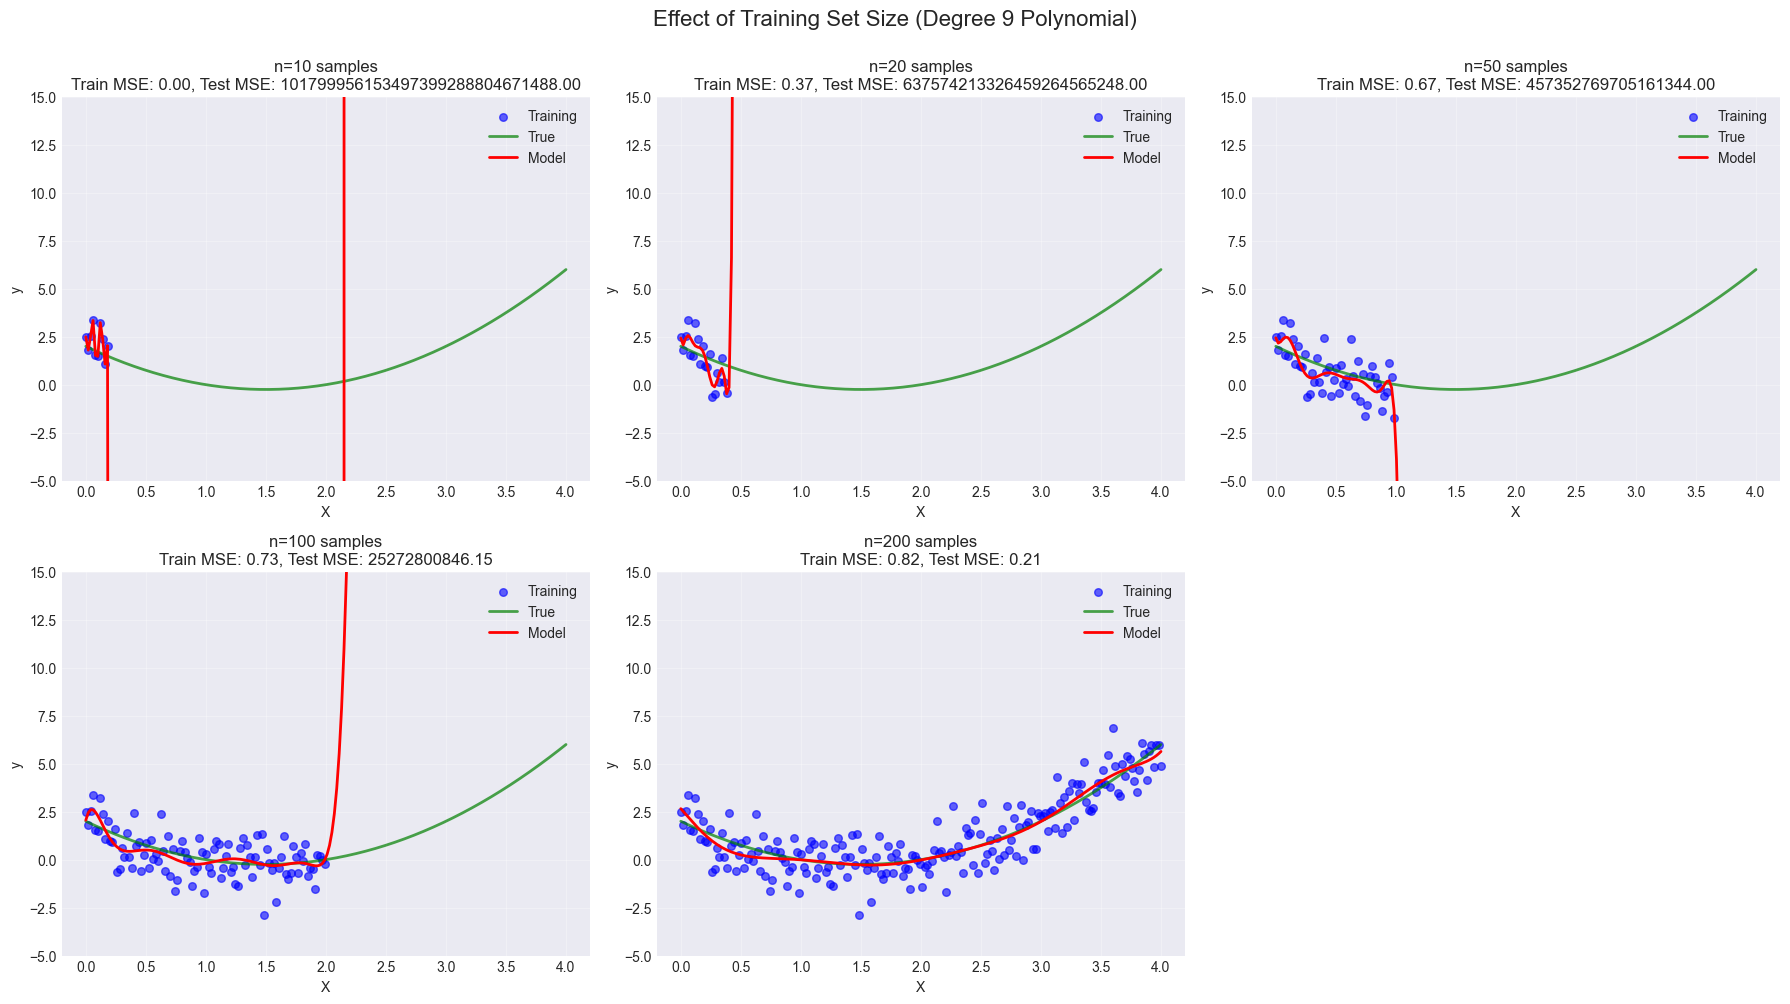


Key Insight:
More training data helps reduce overfitting! Even with a complex model,
having more data allows it to better learn the true underlying pattern.


In [11]:
# Generate more data
np.random.seed(42)
X_large = np.linspace(0, 4, 200)
y_large = true_function(X_large) + np.random.normal(0, 1, 200)

# Try different training set sizes
train_sizes = [10, 20, 50, 100, 200]
degree = 9  # Use a relatively high degree

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, n_samples in enumerate(train_sizes):
    # Sample training data
    X_sample = X_large[:n_samples].reshape(-1, 1)
    y_sample = y_large[:n_samples]
    
    # Fit model
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])
    model.fit(X_sample, y_sample)
    
    # Calculate errors
    train_mse = mean_squared_error(y_sample, model.predict(X_sample))
    test_mse = mean_squared_error(y_test, model.predict(X_test_r))
    
    # Plot
    ax = axes[idx]
    ax.scatter(X_sample, y_sample, color='blue', s=30, alpha=0.6, label='Training')
    ax.plot(x_smooth, true_function(x_smooth), 'g-', linewidth=2, alpha=0.7, label='True')
    ax.plot(x_smooth, model.predict(x_smooth_r), 'r-', linewidth=2, label='Model')
    ax.set_title(f'n={n_samples} samples\nTrain MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-5, 15)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle(f'Effect of Training Set Size (Degree {degree} Polynomial)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("More training data helps reduce overfitting! Even with a complex model,")
print("having more data allows it to better learn the true underlying pattern.")

## Summary

### Key Takeaways

1. **There's no free lunch:** reducing bias increases variance and vice versa

2. **Monitor both training and test error:** their relationship reveals whether you're under/overfitting

3. **More data reduces variance:** it's often the best remedy for overfitting, and can keep bias also low in a certain way...

4. **Regularization controls complexity:** L1/L2 penalties, dropout, early stopping

5. **Cross-validation estimates generalization:** don't rely on a single train/test split

### Quick Reference

**To reduce bias:**
- Increase model complexity
- Add more features
- Reduce regularization

**To reduce variance:**
- Get more training data
- Reduce model complexity
- Add regularization
- Use ensemble methods
- Feature selection